In [10]:
from sklearn import svm, metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
import joblib
from sklearn.inspection import permutation_importance 
import shap
import matplotlib.pyplot as plt
import os


# CNN features

In [11]:
features_efficient_net = np.load('./data/embeddings.npz', allow_pickle=True)
features_efficient_net
features_cnn_data = features_efficient_net

In [12]:
features_cnn_data['embeddings'].shape


(17264, 2048)

# Classic features

In [13]:
dataset = pd.read_csv('./data/02_dataset_w_features.csv', index_col=0)
dataset = dataset.sort_values('image').reset_index(drop=True)
# Filter rows where total_y and total_x are 0
mask = (dataset['total_x'] == 0.0) & (dataset['total_y'] == 0.0)
dataset = dataset[~mask].dropna()
dataset = dataset.drop_duplicates(subset=['image'], keep=False, inplace=False, ignore_index=False)
dataset

,image,dx,path,diameter,compactness,circularity,saturation_std,val_std,total_x,total_y,...,p16,p17,p18,p19,p20,p21,p22,p23,p24,p25
0,ISIC_0000000,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000000.jpg,215.0,15.028339,0.836178,14.867868,48.596631,0.735999,0.807093,...,828.0,630.0,511.0,456.0,425.0,419.0,484.0,586.0,1073.0,11004.0
1,ISIC_0000001,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000001.jpg,93.0,14.465422,0.868718,39.563723,40.721247,0.527757,0.834138,...,222.0,157.0,138.0,108.0,82.0,65.0,55.0,66.0,155.0,1540.0
2,ISIC_0000002,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000002.jpg,199.0,15.029097,0.836136,29.217215,30.506347,0.519741,0.674537,...,644.0,452.0,441.0,363.0,298.0,319.0,362.0,371.0,808.0,7395.0
3,ISIC_0000003,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000003.jpg,224.0,15.630267,0.803977,41.837675,39.772489,0.737595,0.825801,...,589.0,487.0,391.0,370.0,403.0,457.0,405.0,434.0,749.0,8703.0
4,ISIC_0000004,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000004.jpg,154.0,14.947698,0.840689,30.712033,22.264115,0.199741,0.552067,...,230.0,214.0,169.0,175.0,208.0,198.0,255.0,292.0,639.0,5668.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17259,ISIC_0073241,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073241.jpg,201.0,15.633038,0.803834,20.542154,12.875236,0.462161,0.581317,...,497.0,447.0,382.0,443.0,467.0,528.0,540.0,503.0,1199.0,10778.0
17260,ISIC_0073244,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073244.jpg,243.0,14.954783,0.840291,22.701976,28.670436,0.793519,0.796575,...,963.0,723.0,589.0,520.0,472.0,543.0,612.0,687.0,1440.0,12453.0
17261,ISIC_0073245,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073245.jpg,186.0,14.806641,0.848698,35.277772,23.732672,0.680089,0.794475,...,540.0,501.0,423.0,414.0,398.0,359.0,390.0,417.0,1114.0,8766.0
17262,ISIC_0073249,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073249.jpg,244.0,16.619260,0.756133,26.627686,37.776683,0.817845,0.594902,...,1204.0,1002.0,847.0,727.0,695.0,691.0,720.0,677.0,1562.0,12658.0


### Filter valid

In [14]:
valid_ids = dataset['image'].values
mask_ids = np.isin(features_cnn_data['base_ids'], valid_ids)
embeddings_valid = features_cnn_data['embeddings'][mask_ids]
id_embeddings = features_cnn_data['base_ids'][mask_ids]

In [15]:
X_classic = dataset[['diameter', 'circularity', 'total_x', 'total_y']] 
X_cnn = embeddings_valid
y = dataset['dx'].values

### Split

In [16]:
X_train_classic, X_test_classic, X_train_cnn, X_test_cnn, y_train, y_test = train_test_split(X_classic, X_cnn, y, test_size=0.2, stratify=y, random_state=42) 

### Normalize and Stack features

In [17]:
X_train_classic_pd = pd.concat([X_train_classic.reset_index(drop=True), pd.DataFrame({'dx':y_train}).reset_index(drop=True)], axis=1)
X_train_classic_pd


,diameter,circularity,total_x,total_y,dx
0,84.0,0.845578,0.425323,0.767490,NV
1,164.0,0.801118,0.129290,0.751820,NV
2,54.0,0.861179,0.073889,0.833966,NV
3,113.0,0.770715,0.323160,0.246564,NV
4,175.0,0.732252,0.665331,0.630552,NV
...,...,...,...,...,...
13806,46.0,0.854097,0.694301,0.696498,NV
13807,195.0,0.862314,0.886750,0.700694,MEL
13808,256.0,0.709162,0.508629,0.508435,NV
13809,82.0,0.825277,0.355268,0.605344,NV


In [18]:
scaler_classic = StandardScaler()
scaler_classic.fit(X_train_classic)
X_scaled_train_classic = scaler_classic.transform(X_train_classic)
X_scaled_test_classic = scaler_classic.transform(X_test_classic)


scaler_cnn = StandardScaler()
scaler_cnn.fit(X_train_cnn)
X_scaled_train_cnn = scaler_cnn.transform(X_train_cnn)
X_scaled_test_cnn = scaler_cnn.transform(X_test_cnn)



label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [19]:
# Apply pca over cnn features.
pca = PCA(n_components=0.95)
X_cnn_train_pca = pca.fit_transform(X_scaled_train_cnn)
X_cnn_test_pca = pca.transform(X_scaled_test_cnn)

In [20]:
pca.explained_variance_ratio_.sum()

np.float32(0.95005906)

In [21]:
X_train_stacked = np.hstack([X_scaled_train_classic, X_cnn_train_pca ])
X_test_stacked = np.hstack([X_scaled_test_classic, X_cnn_test_pca])

In [22]:
n_melanoma = np.sum(y_train_encoded == 0)
n_nevos = np.sum(y_train_encoded == 1)

ratio = n_nevos / n_melanoma

print(ratio)

2.859977641140302


In [23]:

undersample = RandomUnderSampler(random_state=42, sampling_strategy=0.8)

X_train_stacked, y_train_encoded = undersample.fit_resample(X_train_stacked, y_train_encoded)

In [24]:
pca.explained_variance_ratio_.sum()

np.float32(0.95005906)

# SVM classifier

In [25]:
parameters = {'kernel': ('linear', 'rbf'), 'C': [0.1, 0.01, 1,10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]}
model_svm = svm.SVC(probability=True)
gridSe = GridSearchCV(model_svm, parameters)
gridSe.fit(X_train_stacked, y_train_encoded)

model_svm = gridSe.best_estimator_

joblib.dump(gridSe.best_estimator_, './data/model_svm_wo_lbp_and_colors_4.pkl')

KeyboardInterrupt: 

AUC: 0.9067332257630765


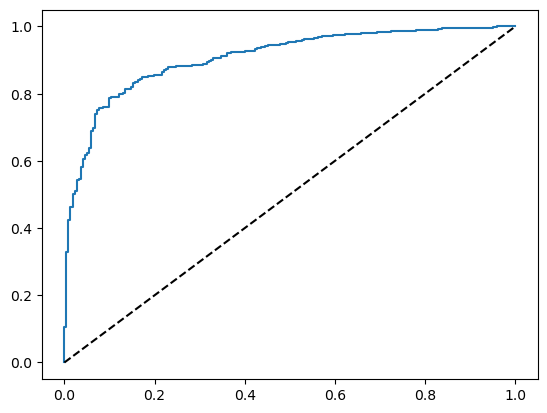

In [ ]:
y_scores = model_svm.decision_function(X_test_stacked)

fpr, tpr, thresholds = metrics.roc_curve(y_test_encoded, y_scores)


roc_auc = metrics.auc(fpr, tpr)
print("AUC:", roc_auc)

j = tpr - fpr

optimal_thres = thresholds[np.argmax(j)]


plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--') # Random guess line
plt.show()

In [27]:
model_svm = joblib.load('./data/model_svm_wo_lbp_and_colors_4.pkl')

In [28]:
model_svm.fit(X_train_stacked, y_train_encoded)

,C,100
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
y_svm_pred = model_svm.predict(X_test_stacked)

print(classification_report(y_test_encoded, y_svm_pred))

              precision    recall  f1-score   support

           0       0.61      0.81      0.70       894
           1       0.92      0.82      0.87      2559

    accuracy                           0.82      3453
   macro avg       0.77      0.81      0.78      3453
weighted avg       0.84      0.82      0.83      3453



In [ ]:
# joblib.dump(model_svm, './data/model_svm_08_sampling_strgy.pkl')
# joblib.dump(scaler_classic, './data/scaler_classic.pkl')
# joblib.dump(scaler_cnn, './data/scaler_cnn.pkl')
# joblib.dump(pca, './data/pca.pkl')
# joblib.dump(label_encoder, './data/label_encoder.pkl')

['./data/label_encoder.pkl']